In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df= pd.read_csv('procurement_requests_5000.csv',parse_dates=['request_date'])

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")


In [4]:
print(f'Всего заявок: {len(df):,}')
print(f'Период: с {df["request_date"].min().date()} по {df["request_date"].max().date()}')
print(f'Количество подразделений: {df["department"].nunique()}')

Всего заявок: 5,000
Период: с 2026-01-01 по 2026-12-31
Количество подразделений: 7


In [5]:
stats = {
    'Средняя сумма заявки': f"{df['amount'].mean():,.2f} ₽",
    'Медианная сумма': f"{df['amount'].median():,.2f} ₽",
    'Среднее время обработки': f"{df['total_time_hours'].mean():.1f} ч",
    'Медианное время обработки': f"{df['total_time_hours'].median():.1f} ч",
    'Среднее количество возвратов': f"{df['return_count'].mean():.2f}",
    'Среднее количество уточнений': f"{df['clarification_count'].mean():.2f}",
    'Доля одобренных': f"{df[df['final_status'] == 'Одобрена'].shape[0] / len(df) * 100:.1f}%",
    'Доля отклонённых': f"{df[df['final_status'] == 'Отклонена'].shape[0] / len(df) * 100:.1f}%",
    'Доля в процессе': f"{df[df['final_status'] == 'В процессе'].shape[0] / len(df) * 100:.1f}%"
}
for key, value in stats.items():
    print(f'{key:35} {value}')

Средняя сумма заявки                127,224.23 ₽
Медианная сумма                     42,525.35 ₽
Среднее время обработки             25.8 ч
Медианное время обработки           16.9 ч
Среднее количество возвратов        0.18
Среднее количество уточнений        0.63
Доля одобренных                     84.8%
Доля отклонённых                    7.5%
Доля в процессе                     7.7%


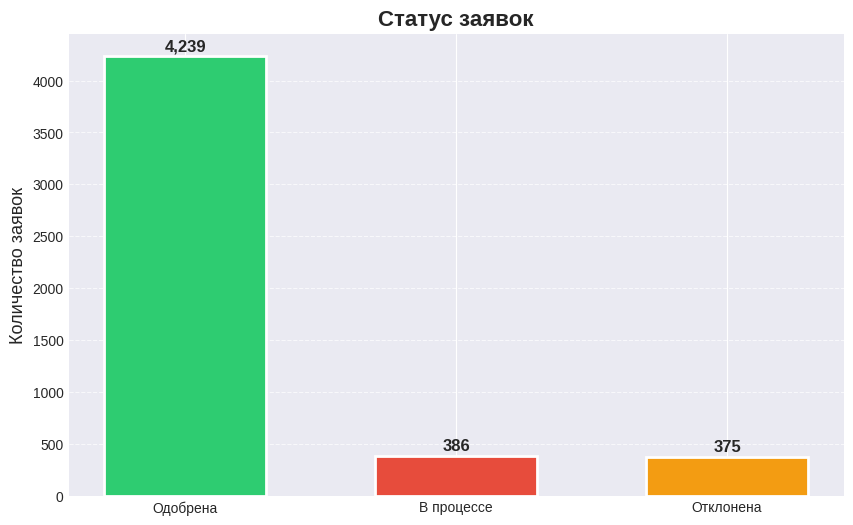

In [6]:
plt.figure(figsize=(10, 6))
status_counts = df['final_status'].value_counts()
status_colors = ['#2ECC71', '#E74C3C', '#F39C12']
bars = plt.bar(
    status_counts.index,
    status_counts.values,
    color=status_colors,
    edgecolor='white',
    linewidth=2,
    width=0.6
)
plt.title('Статус заявок', fontsize=16, fontweight='bold')
plt.ylabel('Количество заявок', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, count in zip(bars, status_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{count:,}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )
plt.show()

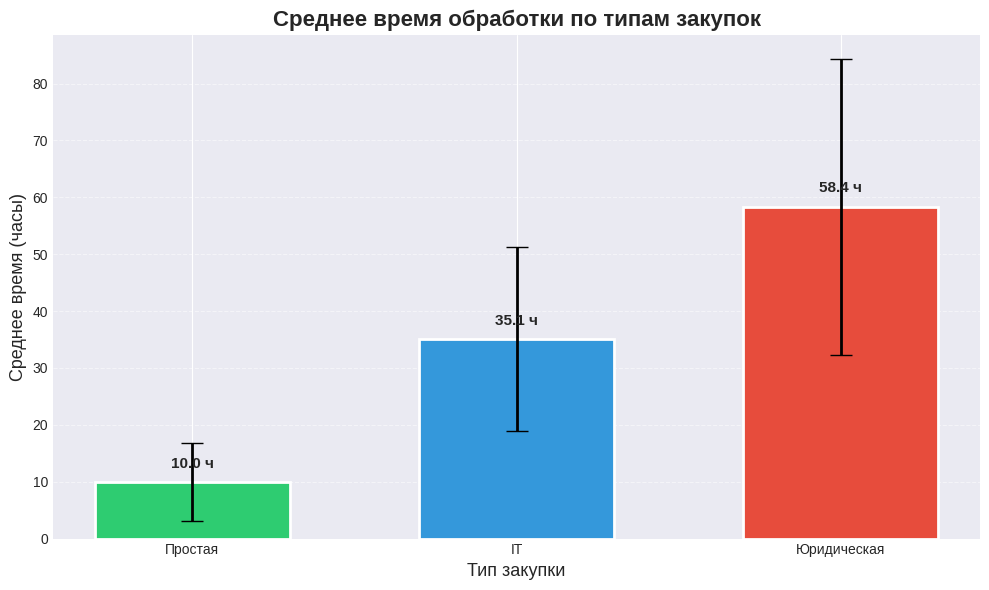

In [15]:
plt.figure(figsize=(10, 6))

stats = df.groupby('purchase_type')['total_time_hours'].agg(['mean', 'std', 'count']).reset_index()
order = ['Простая', 'IT', 'Юридическая']
stats['purchase_type'] = pd.Categorical(stats['purchase_type'], categories=order, ordered=True)
stats = stats.sort_values('purchase_type')

colors = ['#2ECC71', '#3498DB', '#E74C3C']

bars = plt.bar(
    stats['purchase_type'],
    stats['mean'],
    yerr=stats['std'],
    capsize=8,
    color=colors,
    edgecolor='white',
    linewidth=2,
    width=0.6,
    error_kw={'linewidth': 2, 'ecolor': 'black'}
)

for bar, mean_val in zip(bars, stats['mean']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{mean_val:.1f} ч',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Среднее время обработки по типам закупок', fontsize=16, fontweight='bold')
plt.xlabel('Тип закупки', fontsize=13)
plt.ylabel('Среднее время (часы)', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Чем сложнее тип закупки, тем дольше обработка. Юридические закупки занимают в 6 раз больше времени, чем простые.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


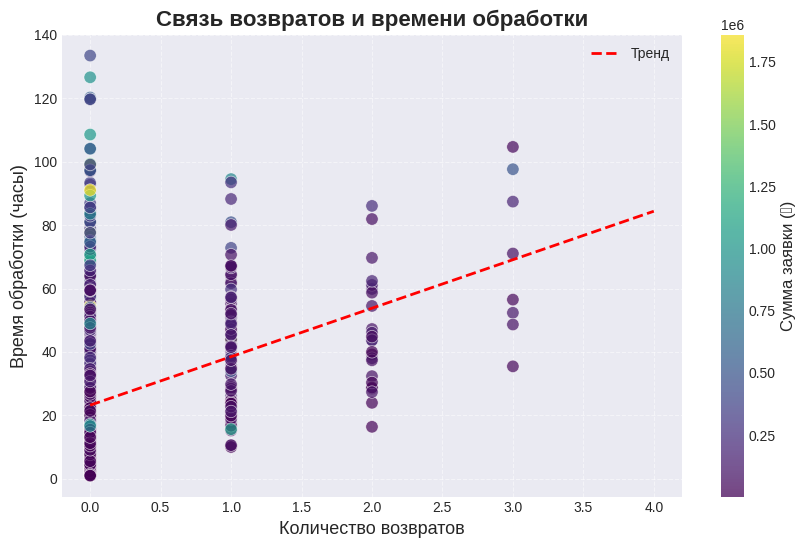

In [8]:
plt.figure(figsize=(10, 6))
df_sample = df.sample(n=1000, random_state=42)
scatter = plt.scatter(
    df_sample['return_count'],
    df_sample['total_time_hours'],
    c=df_sample['amount'],
    cmap='viridis',
    alpha=0.7,
    s=80,
    edgecolors='white',
    linewidth=0.5
)
plt.title('Связь возвратов и времени обработки', fontsize=16, fontweight='bold')
plt.xlabel('Количество возвратов', fontsize=13)
plt.ylabel('Время обработки (часы)', fontsize=13)
plt.grid(linestyle='--', alpha=0.5)
cbar = plt.colorbar(scatter)
cbar.set_label('Сумма заявки (₽)', fontsize=12)

if len(df_sample) > 1:
    z = np.polyfit(df_sample['return_count'], df_sample['total_time_hours'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(0, 4, 100)
    plt.plot(x_trend, p(x_trend), 'r--', linewidth=2, label='Тренд')
    plt.legend()
plt.show()

Каждый возврат добавляет в среднем 10–15 часов к времени обработки

Заявки с возвратами обрабатываются дольше, и разброс времени увеличивается

/tmp/ipykernel_747/3743235998.py:24: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()


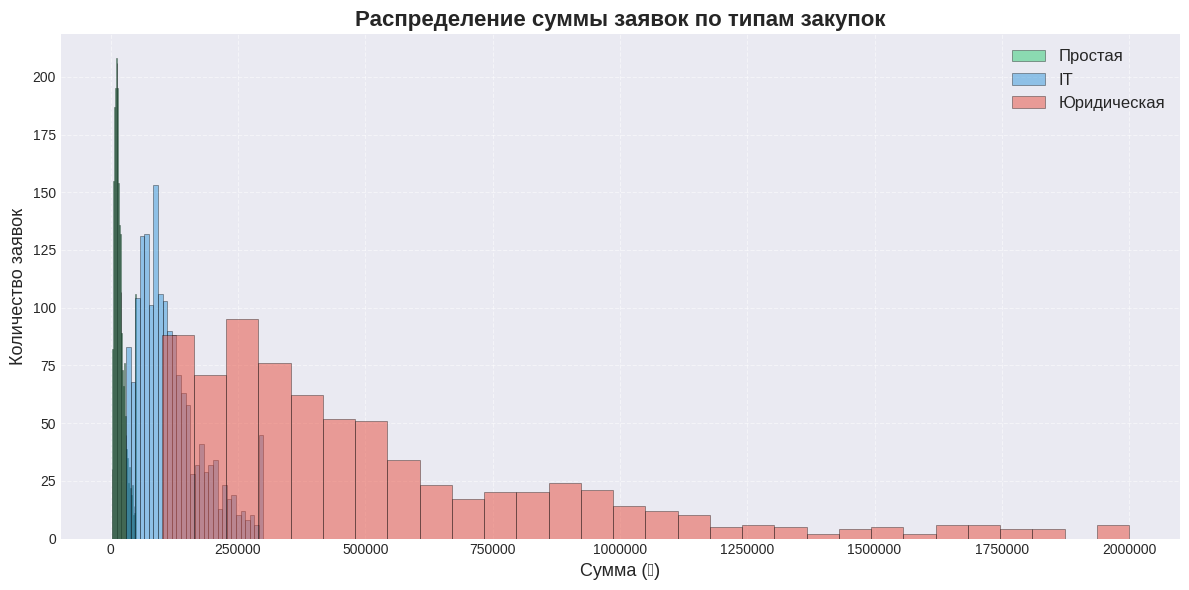

In [12]:
plt.figure(figsize=(12, 6))

order = ['Простая', 'IT', 'Юридическая']
colors = ['#2ECC71', '#3498DB', '#E74C3C']

for i, purchase_type in enumerate(order):
    subset = df[df['purchase_type'] == purchase_type]['amount']
    plt.hist(
        subset,
        bins=30,
        alpha=0.5,
        color=colors[i],
        label=purchase_type,
        edgecolor='black',
        linewidth=0.5
    )

plt.title('Распределение суммы заявок по типам закупок', fontsize=16, fontweight='bold')
plt.xlabel('Сумма (₽)', fontsize=13)
plt.ylabel('Количество заявок', fontsize=13)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

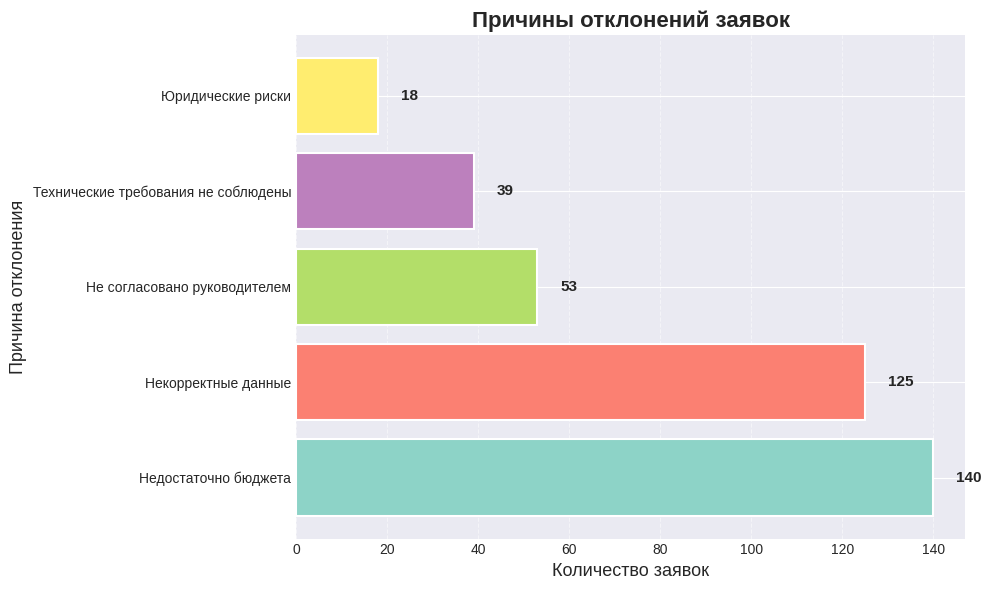

In [10]:
plt.figure(figsize=(10, 6))
rejected_df = df[df['final_status'] == 'Отклонена']

if len(rejected_df) > 0 and rejected_df['rejection_reason'].notna().any():
    reason_counts = rejected_df['rejection_reason'].value_counts()
    colors_reasons = plt.cm.Set3(np.linspace(0, 1, len(reason_counts)))
    bars = plt.barh(
        reason_counts.index,
        reason_counts.values,
        color=colors_reasons,
        edgecolor='white',
        linewidth=1.5
    )
    plt.title('Причины отклонений заявок', fontsize=16, fontweight='bold')
    plt.xlabel('Количество заявок', fontsize=13)
    plt.ylabel('Причина отклонения', fontsize=13)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    for bar, count in zip(bars, reason_counts.values):
        plt.text(
            bar.get_width() + 5,
            bar.get_y() + bar.get_height()/2,
            f'{count:,}',
            va='center',
            fontsize=11,
            fontweight='bold'
        )
else:
    plt.text(0.5, 0.5, 'Нет данных об отклонениях',
             ha='center', va='center', fontsize=16, color='gray')
    plt.title('Причины отклонений заявок', fontsize=16, fontweight='bold')
    plt.xlabel('Количество заявок', fontsize=13)
    plt.ylabel('Причина отклонения', fontsize=13)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
plt.tight_layout()
plt.show()